In [1]:
from Drafts.testShuffleEvents import shuffled
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import isautilities as isau
import xarray as xr
import sklearn as sk
from tqdm import tqdm

import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results' / 'Figures' / 'ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _periEventGLM(session, regs=None, target:str='pfc', when=None, method:str='poisson', bin:float=0.1, limits=(-0.25,0.25), step:int=1, delay:float=0, shuffle:int=1, verbose:bool=False):
    # predict peri-event spikes with region spike matrices just before (1 time bin)
    # regs doesn't allow to mix regions for now

    # load data
    R = fma.regions.regions(session,phases=when,events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    events, is_coupled = isau.loadHpcPfcEvents(session,coupl=True)

    # X
    peth = {}
    for r in regs:
        spikes = R.spikes(regs=r)
        peth[r], times, _ = fma.analysis.PETH(spikes[:,0],events['ripples'],groups=spikes[:,1],g_range=R.units(regs=r),limits=limits,bin=bin,step=step,fast=True) # (events, time, units)
    n_times = len(times)

    # y
    spikes = R.spikes(regs=target)
    limits = (-bin/2 + delay, bin/2 + delay)
    peth['target'], _, _ = fma.analysis.PETH(spikes[:,0],events['ripples'],groups=spikes[:,1],g_range=R.units(regs=target),limits=limits,bin=bin,fast=True) # (events, time, units)
    n_targets = peth['target'].shape[-1]

    n_cv = 5
    def cv_score(X,y):
        match method:
            case 'poisson':
                cv = sk.model_selection.KFold(n_splits=n_cv,shuffle=True,random_state=42)
                model = sk.linear_model.PoissonRegressor(alpha=100,max_iter=5000) # L2 penalty
                return -sk.model_selection.cross_val_score(model,X,y,cv=cv,scoring='neg_mean_poisson_deviance')
            case 'logistic':
                cv = sk.model_selection.StratifiedKFold(n_splits=n_cv,shuffle=True,random_state=42)
                model = sk.linear_model.LogisticRegression(C=0.00001,max_iter=5000) # L2 penalty
                y = (y > 0).astype(float)
                return sk.model_selection.cross_val_score(model,X,y,cv=cv,scoring='average_precision')

    rng = np.random.default_rng()
    scores = np.full((len(regs),shuffle+1,n_times,n_targets,n_cv),np.nan)
    for i, r in enumerate(regs):
        verbose and print(r.upper())
        iterator = tqdm(enumerate(times),total=n_times,leave=False,desc="  delays:") if verbose else enumerate(times)
        for t, time in iterator:

            X = peth[r][:,t]
            for j in range(n_targets):

                y = peth['target'][:,0,j]
                if np.count_nonzero(y) < 5:
                    continue

                # 1. observed
                scores[i,0,t,j] = cv_score(X,y)

                # 2. surrogate
                for k in range(shuffle):
                    rng.shuffle(y)
                    scores[i,k+1,t,j] = cv_score(X,y)

        scores = xr.DataArray(scores,dims=['reg','shuffle','t','i','cv'],coords={'reg': regs, 'shuffle': [False]+[True]*shuffle, 't': times,
                              'target': target, 'delay': delay, 'bin': bin, 'rat': int(R.rat)})
        match shuffle:
            case 0: gain = scores.sel(shuffle=False).mean(dim='cv') * np.nan
            case 1: gain = scores.sel(shuffle=False).mean(dim='cv') / scores.sel(shuffle=True).mean(dim='cv')
            case _: gain = scores.sel(shuffle=False).mean(dim='cv') / scores.sel(shuffle=True).mean(dim='cv').mean(dim='shuffle')

    return scores, gain

test bin 0.02 s with another session, should also try defining gain as diff?

In [3]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][26]
print(session)
scores, gain = _periEventGLM(session,regs=['hpc','nr','pfc'],method='logistic',bin=0.05,step=3,delay=0.0,shuffle=50,verbose=True)

/mnt/hubel-data-140/karadoc/Rat004_20240315/Rat004_20240315.xml
HPC


NR


PFC


In [ ]:
# TO DO: perc of neurons which have p < 0.05
fma.analysis.MCpValue(score.sel(shuffle=True),score.sel(shuffle=False))

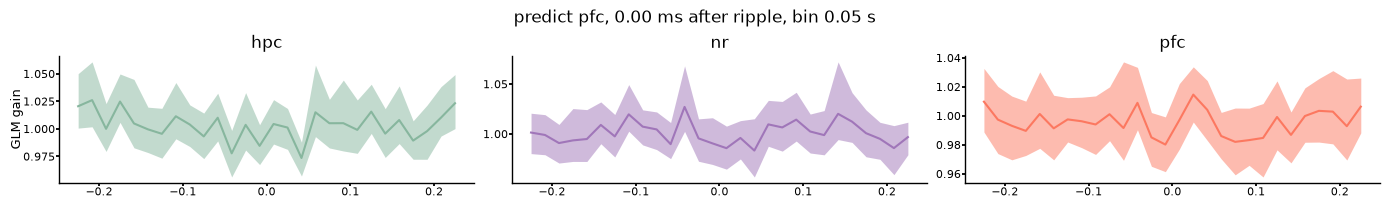

In [6]:
# see gain
fig, ax = fma.plotting.makeFigure(f'predict {gain.target.values}, {gain.delay.values * 1000:.2f} ms after ripple, bin {gain.bin.values} s',size=(35,5),n=(1,len(scores.reg)))
for i, r in enumerate(gain.reg.values):
    fma.plotting.semPlot(gain.t,gain.sel(reg=r).T,color=isau.paperColors(r),ax=ax[i])
    ax[i].set(title=r)#,ylim=(1-0.0006,1.001))
ax[0].set(ylabel='GLM gain');

tests done

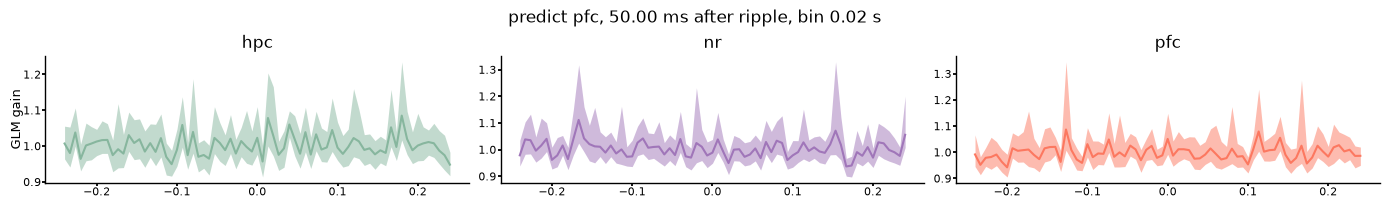

In [8]:
# see gain
fig, ax = fma.plotting.makeFigure(f'predict {gain.target.values}, {gain.delay.values * 1000:.2f} ms after ripple, bin 0.02 s',size=(35,5),n=(1,len(scores.reg)))
for i, r in enumerate(gain.reg.values):
    fma.plotting.semPlot(gain.t,gain.sel(reg=r).T,color=isau.paperColors(r),ax=ax[i])
    ax[i].set(title=r)#,ylim=(1-0.0006,1.001))
ax[0].set(ylabel='GLM gain');

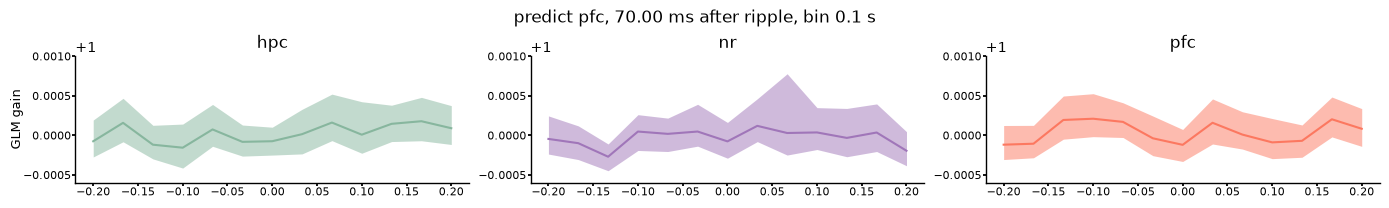

In [7]:
# see gain
fig, ax = fma.plotting.makeFigure(f'predict {gain.target.values}, {gain.delay.values * 1000:.2f} ms after ripple, bin 0.1 s',size=(35,5),n=(1,len(scores.reg)))
for i, r in enumerate(gain.reg.values):
    fma.plotting.semPlot(gain.t,gain.sel(reg=r).T,color=isau.paperColors(r),ax=ax[i])
    ax[i].set(title=r,ylim=(1-0.0006,1.001))
ax[0].set(ylabel='GLM gain');

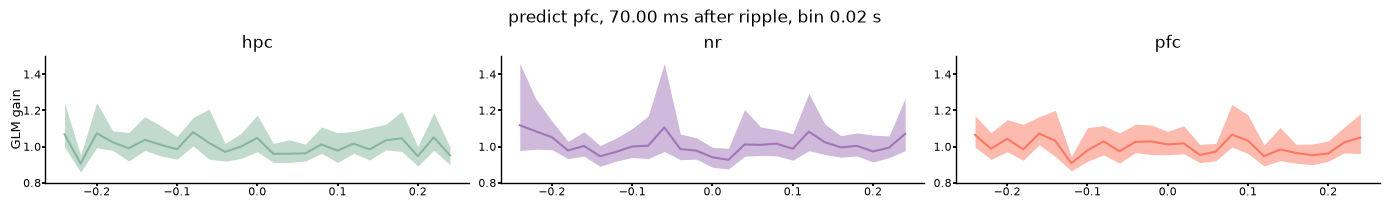

In [11]:
# see gain. shuffle 100
fig, ax = fma.plotting.makeFigure(f'predict {gain1.target.values}, {gain1.delay.values * 1000:.2f} ms after ripple, bin 0.02 s',size=(35,5),n=(1,len(scores1.reg)))
for i, r in enumerate(gain1.reg.values):
    fma.plotting.semPlot(gain1.t,gain1.sel(reg=r).T,color=isau.paperColors(r),ax=ax[i])
    ax[i].set(title=r,ylim=(0.8,1.5))
ax[0].set(ylabel='GLM gain');

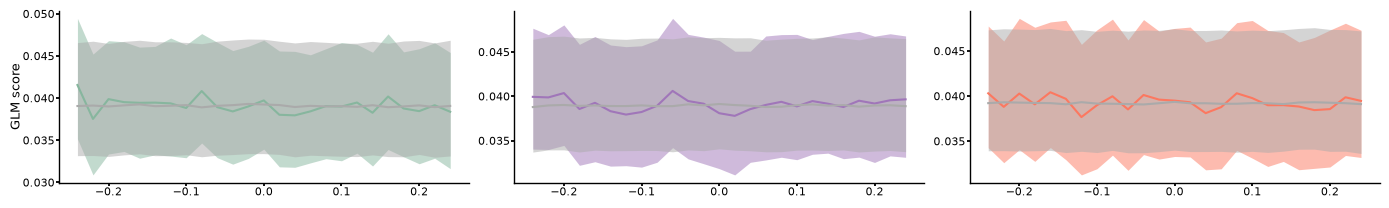

In [12]:
# see scores shuffle 100
fig, ax = fma.plotting.makeFigure(size=(35,5),n=(1,len(scores1.reg)))
for i, r in enumerate(scores1.reg.values):
    fma.plotting.semPlot(scores1.t,scores1.sel(reg=r,shuffle=False).mean(dim='cv').T,color=isau.paperColors(r),ax=ax[i])
    fma.plotting.semPlot(scores1.t,scores1.sel(reg=r,shuffle=True).mean(dim=['cv','shuffle']).T,color=isau.paperColors('shuffle'),ax=ax[i])
    #ax[i].set(title=r,ylim=(1-0.0006,1.001))
ax[0].set(ylabel='GLM score');

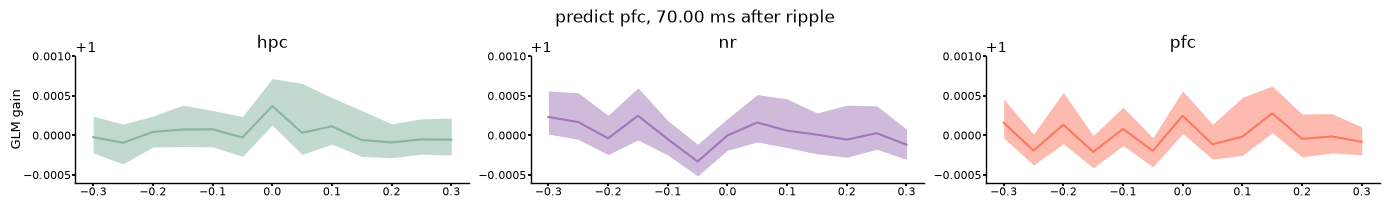

In [20]:
# see gain
fig, ax = fma.plotting.makeFigure(f'predict {gain.target.values}, {gain.delay.values * 1000:.2f} ms after ripple',size=(35,5),n=(1,len(scores.reg)))
for i, r in enumerate(gain.reg.values):
    fma.plotting.semPlot(gain.t,gain.sel(reg=r).T,color=isau.paperColors(r),ax=ax[i])
    ax[i].set(title=r,ylim=(1-0.0006,1.001))
ax[0].set(ylabel='GLM gain'); #ax[0,0].set(ylabel='ISA'), ax[1,0].set(ylabel='nISA');

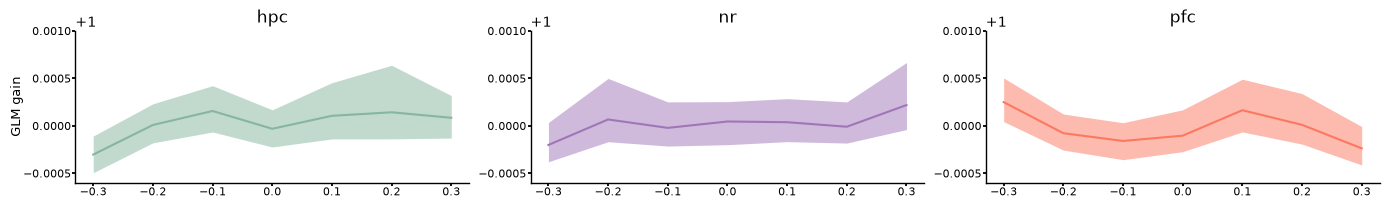

In [6]:
# see gain
fig, ax = fma.plotting.makeFigure(size=(35,5),n=(1,len(scores.reg)))
for i, r in enumerate(scores.reg.values):
    fma.plotting.semPlot(gain.t,gain.sel(reg=r).T,color=isau.paperColors(r),ax=ax[i])
    ax[i].set(title=r,ylim=(1-0.0006,1.001))
ax[0].set(ylabel='GLM gain');#ax[0,0].set(ylabel='ISA'), ax[1,0].set(ylabel='nISA');

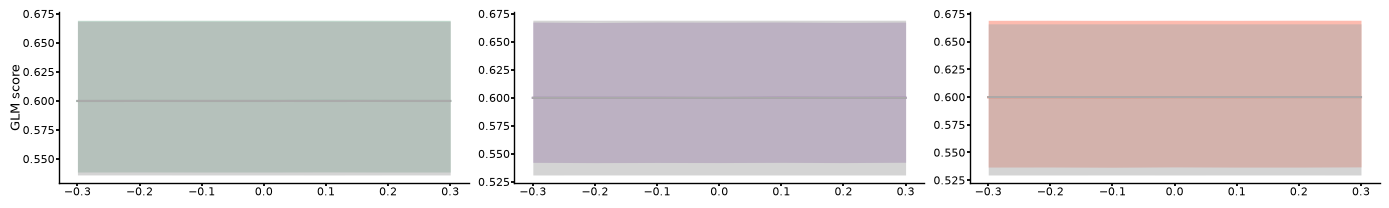

In [6]:
# see scores
fig, ax = fma.plotting.makeFigure(size=(35,5),n=(1,len(scores.reg)))
for i, r in enumerate(scores.reg.values):
    fma.plotting.semPlot(scores.t,scores.sel(reg=r,shuffle=False).mean(dim='cv').T,color=isau.paperColors(r),ax=ax[i])
    fma.plotting.semPlot(scores.t,scores.sel(reg=r,shuffle=True).mean(dim=['cv','shuffle']).T,color=isau.paperColors('shuffle'),ax=ax[i])
    #ax[i].set(title=r,ylim=(1-0.0006,1.001))
ax[0].set(ylabel='GLM score');

/home/pietro/uvEnvs/fmat_edit_12/lib/python3.12/site-packages/scipy/_lib/_util.py:307: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


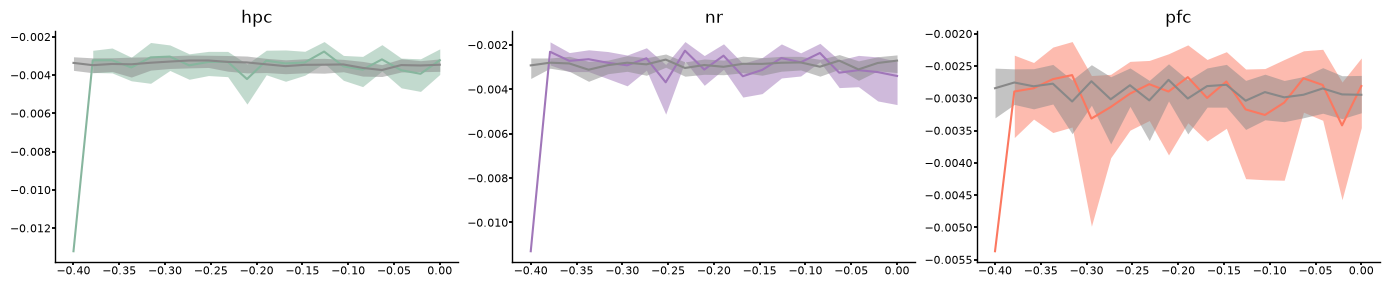

In [5]:
# see scores
fig, ax = fma.plotting.makeFigure(size=(35,7),n=(1,len(scores)))
for i, k in enumerate(keys):
    fma.plotting.semPlot(delay,np.array(scores[k]).T,color=isru.paperColors(k),ax=ax[i])
    fma.plotting.semPlot(delay,np.array(scores_sh[k]).mean(axis=-1).T,color=isru.paperColors('shuffle'),ax=ax[i])
    ax[i].set(title=keys[i])